In [ ]:
# Simple Linear Regression - Übungsbeispiel mit Visualisierung

# benötigte Libraries importieren
import numpy as np
import matplotlib.pyplot as plt
# Für das Beispiel der Gehaltsberechnung
import pandas as pd

In [ ]:
# Datensatz importieren
dataset = pd.read_csv (r"/content/drive/MyDrive/Colab Notebooks/Salary_Data.csv",sep=',')

X = dataset.iloc[:, :-1].values #YearsExperience
y = dataset['Salary'].values #Salary

# Die ersten Zeilen des Datensatzes anzeigen, um die erfolgreiche Ladung zu prüfen
display(dataset.head())

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


### Dateiserienfehler (File Not Found Error)

Der `FileNotFoundError` in der vorherigen Zelle bedeutet, dass das System die Datei `Salary_Data.csv` unter dem angegebenen Pfad nicht finden konnte: `/content/drive/MyDrive/Colab Notebooks/Salary_Data.csv`.

Dies geschieht häufig, wenn:
1.  **Google Drive nicht gemountet ist**: Colab benötigt eine explizite Berechtigung, um auf Ihre Google Drive-Dateien zuzugreifen. Sie müssen es zuerst mounten.
2.  **Falscher Pfad**: Die Datei befindet sich möglicherweise nicht genau unter `/content/drive/MyDrive/Colab Notebooks/`, oder der Dateiname ist anders geschrieben.

Versuchen wir zunächst, Google Drive zu mounten. Falls der Fehler weiterhin besteht, überprüfen Sie bitte den genauen Pfad und die Schreibweise der Datei in Ihrem Google Drive.

In [ ]:
# Google Drive mounten
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Überprüfung des Dateipfads

Bitte stellen Sie sicher, dass Sie die obige Zelle zum Mounten von Google Drive ausgeführt haben. Dann können Sie den Inhalt des Verzeichnisses überprüfen, in dem sich Ihre Datei befinden sollte, um den genauen Dateinamen und Pfad zu bestätigen.

In [ ]:
import os

# Pfad zum Verzeichnis, in dem die Datei erwartet wird
file_directory = '/content/drive/MyDrive/Colab Notebooks/'

# Überprüfen, ob das Verzeichnis existiert
if os.path.exists(file_directory):
    print(f"Inhalt von '{file_directory}':")
    for item in os.listdir(file_directory):
        print(item)
else:
    print(f"Das Verzeichnis '{file_directory}' existiert nicht. Bitte überprüfen Sie den Pfad zu Ihrem Google Drive.")

Inhalt von '/content/drive/MyDrive/Colab Notebooks/':
Salary_Data.csv
test.csv
train.csv
Übung_Titanic.ipynb
Logistische Regression.ipynb
02-Decision Tree Regression.ipynb
Quickstart PyTorch.ipynb
Simple_Linear_Regression.ipynb


### Überprüfung des Google Drive Hauptverzeichnisses

Wenn das Verzeichnis `Colab Notebooks` nicht gefunden wurde, versuchen Sie, das Hauptverzeichnis von Google Drive (`/content/drive/MyDrive/`) aufzulisten, um zu sehen, welche Ordner dort tatsächlich existieren und den genauen Pfad Ihrer Datei zu finden.

In [ ]:
import os

# Pfad zum Hauptverzeichnis von Google Drive
main_drive_path = '/content/drive/MyDrive/'

# Überprüfen, ob das Hauptverzeichnis existiert
if os.path.exists(main_drive_path):
    print(f"Inhalt von '{main_drive_path}':")
    for item in os.listdir(main_drive_path):
        print(item)
else:
    print(f"Das Hauptverzeichnis '{main_drive_path}' existiert nicht. Bitte stellen Sie sicher, dass Google Drive korrekt gemountet ist.")

Inhalt von '/content/drive/MyDrive/':
Privat
Colab Notebooks
nachhaltigkeit
forschungsmethoden
big data
betriebssysteme
Leitfaden zur formalen Gestaltung von Seminar-_&_Abschlussarbeiten.pdf
Aus Chrome gespeichert
augustinum
betriebliche anwendung ki
KI Agenten Frameworks.gsheet
Masterclass AI.gsheet
Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf


In [ ]:
# In den Datensatz schauen
dataset.head()
#print(X[1:4])
#print(y[1:4])

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
# Datensatz teilen in Training Set und Test Set
#from sklearn.model_selection import train_test_split
import sklearn.model_selection as model_selection
# wir definieren die Variablen
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, train_size = 0.65, test_size = 0.35, random_state = 0) #random_state 0 oder 101
# random_state: If int, random_state is the seed used by the random number generator;
# If RandomState instance, random_state is the random number generator;
# If None, the random number generator is the RandomState instance used by np.random.

# Die Simple Lineare Regression auf das Training Set fitten
from sklearn.linear_model import LinearRegression
# Der Parameter 'normalize' wurde aus neueren Versionen von scikit-learn entfernt.
# Wir entfernen ihn, um den TypeError zu beheben.
regressor = LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None)
regressor.fit(X_train, y_train)

LinearRegression()

In [ ]:
#dieses wird das Test Set Ergebnis vorhersagen
y_pred = regressor.predict(X_test)
print(X_train)
print(y_train)
#print(X_test)
#print(y_test)

[[ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]]
[ 66029.  64445.  61111. 113812.  91738.  46205. 121872.  60150.  39891.
  81363.  93940.  57189.  54445. 105582.  43525.  39343.  98273.  67938.
  56957.]


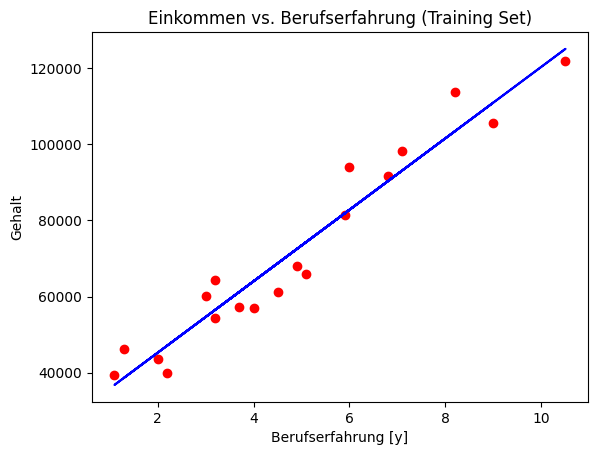

In [ ]:
# Visualisieren des Training Sets
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Einkommen vs. Berufserfahrung (Training Set)')
plt.xlabel('Berufserfahrung [y]')
plt.ylabel('Gehalt')
plt.show()

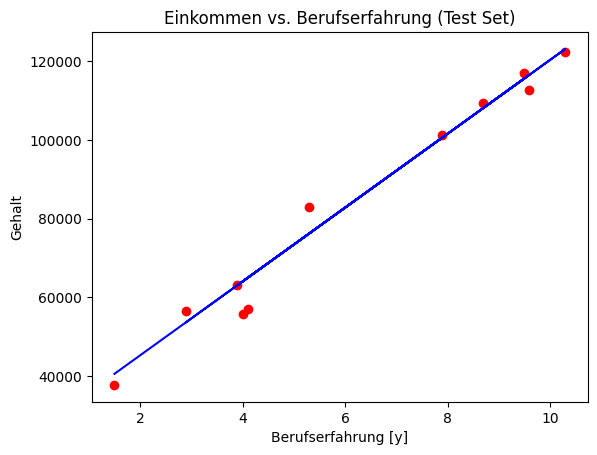

In [ ]:
# Visualisieren des Test Sets
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_test, regressor.predict(X_test), color = 'blue')
plt.title('Einkommen vs. Berufserfahrung (Test Set)')
plt.xlabel('Berufserfahrung [y]')
plt.ylabel('Gehalt')
plt.show()